In [1]:
import numpy as np
import scvelo as scv
import scanpy as sc
import pandas as pd
import topovelo as tpv
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = ''
DATA_NAME = 'slide-tag-mouse-brain'
adata = sc.read_h5ad(f'{DATA_DIR}/{DATA_NAME}-out.h5ad')

# Cell Velocity and Time

In [3]:
stream_plot_config = {
    'width': 3,
    'markersize': 60,
    'density': 2,
    'linewidth': 1,
}

Overwriting the original KNN graph! (.uns, .obsp)


---   Plotting  Results   ---
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 2/32 cores)


  0%|          | 0/4623 [00:00<?, ?cells/s]

    finished (0:00:14) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_spatial', embedded velocity vectors (adata.obsm)


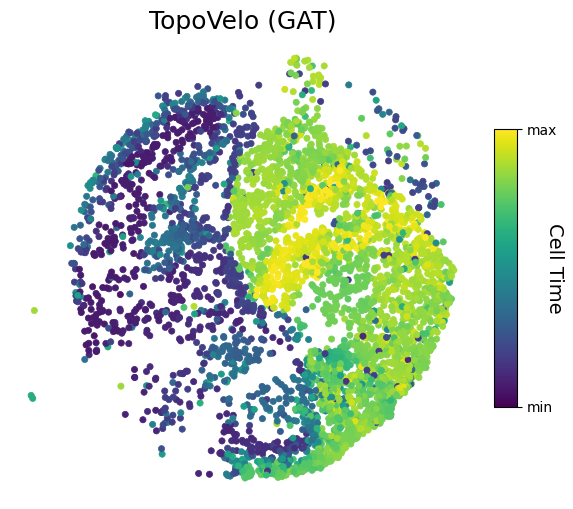

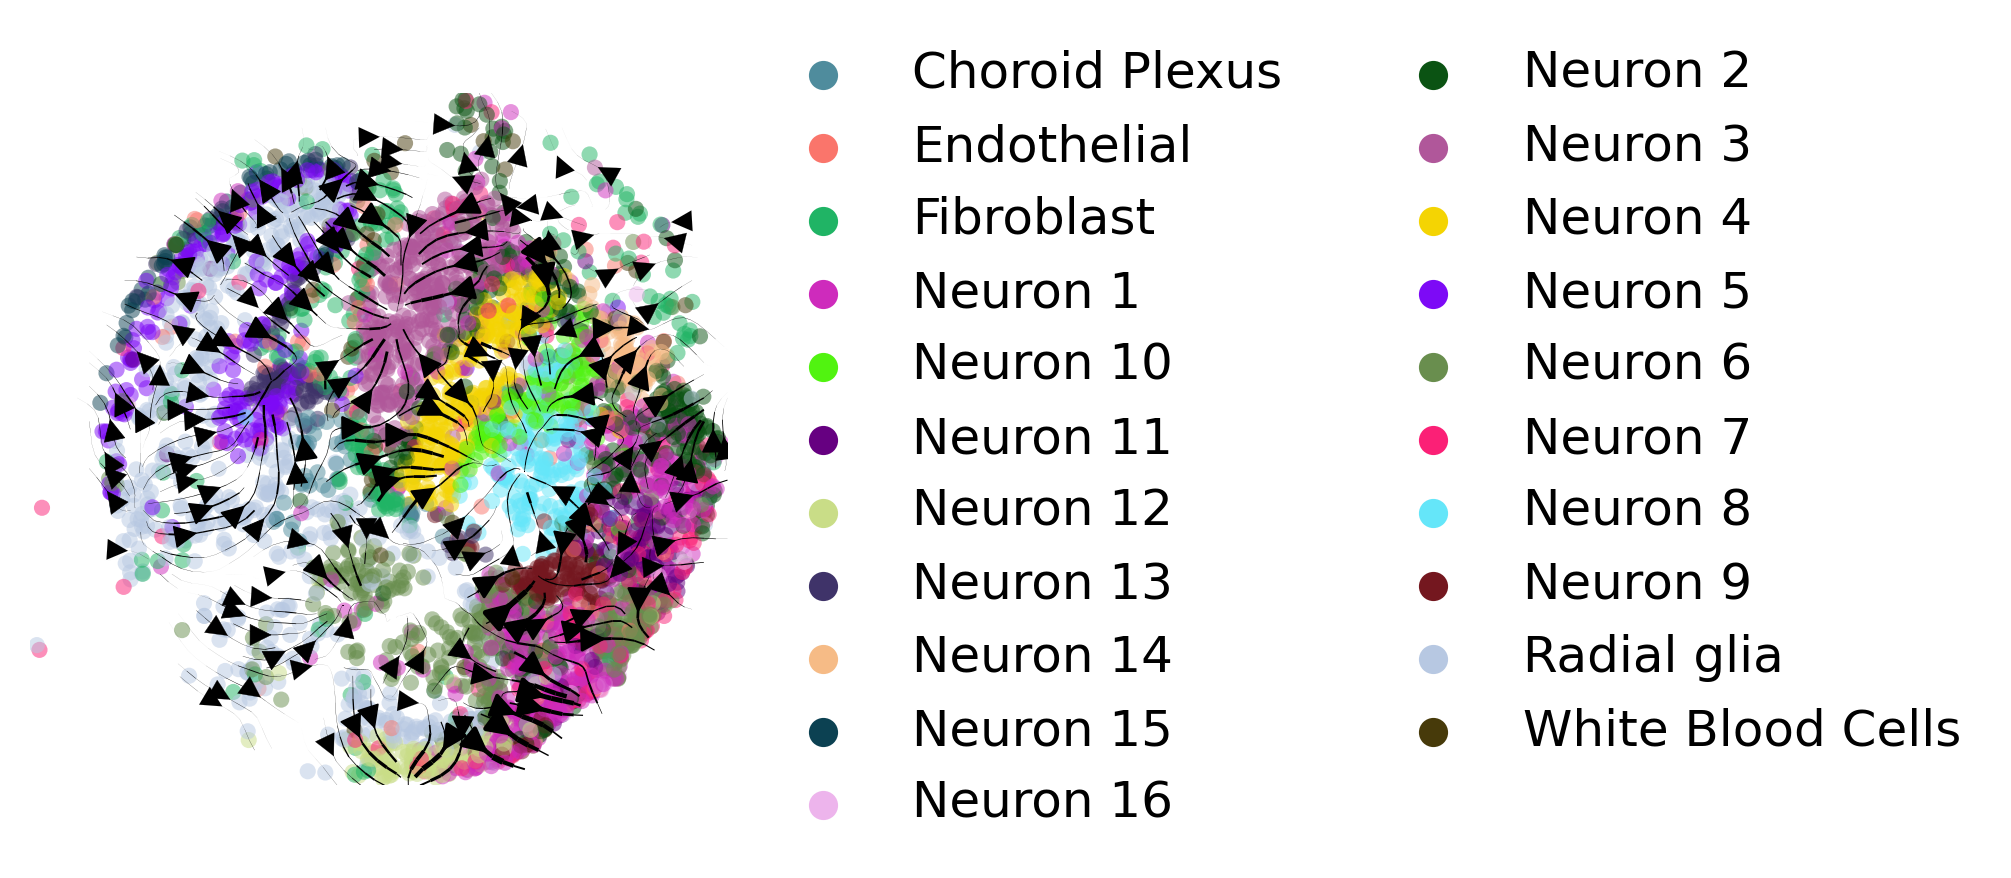

Recovering the original KNN graph from .uns


In [4]:
_ = tpv.post_analysis(
    adata,
    'brain',
    ['TopoVelo (GAT)'],
    ['gat'],
    n_spatial_neighbors=50,
    plot_type=['time', 'cell velocity'],
    stream_plot_config=stream_plot_config,
    dpi=300
)

# Select a subregion

In [5]:
adata_sub = adata[adata.obs['clusters'].isin(['Radial glia', 'Neuron_5', 'Neuron_15'])]

In [6]:
palette = [adata.uns['clusters_colors'][9], adata.uns['clusters_colors'][14], adata.uns['clusters_colors'][19]]
stream_plot_config={
    'width': 8 / 2.54,
    'markersize': 20,
    'palette': palette,
    'legend_loc': 'none',
}

Overwriting the original KNN graph! (.uns, .obsp)


---   Plotting  Results   ---
Computing a spatial graph using KNN on spatial with k=30
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/32 cores)


  0%|          | 0/887 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_spatial', embedded velocity vectors (adata.obsm)


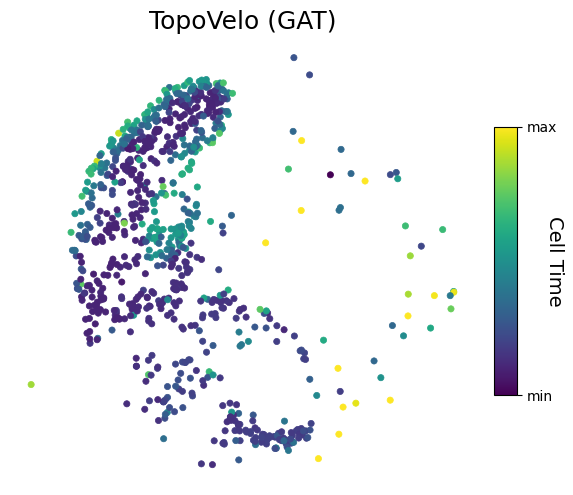

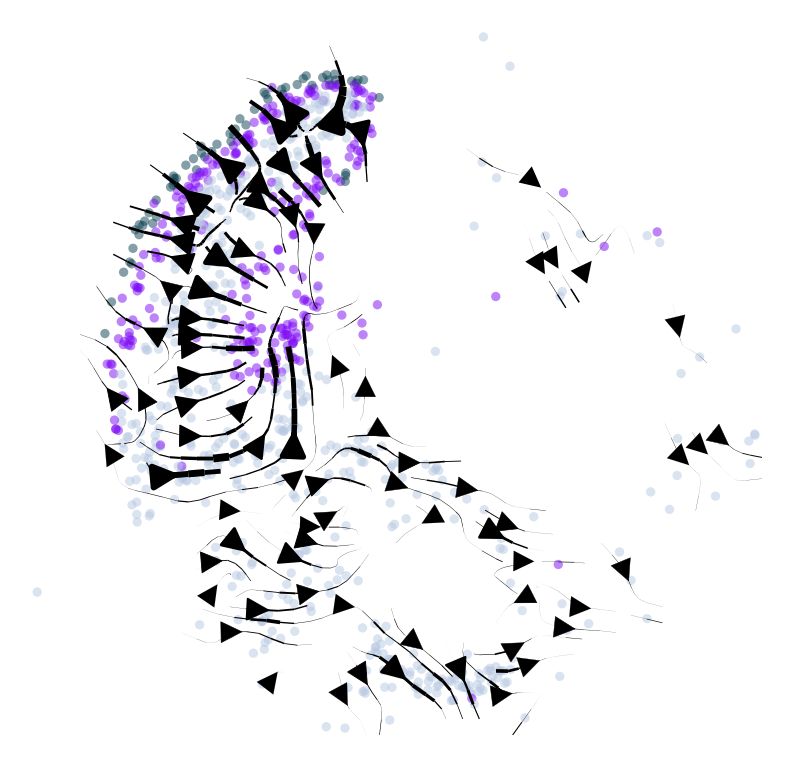

Recovering the original KNN graph from .uns


In [7]:
out = tpv.post_analysis(
    adata_sub,
    'slide-tag-subregion',
    ['TopoVelo (GAT)'],
    ['gat'],
    n_spatial_neighbors=30,
    plot_type=['cell velocity', 'time'],
    stream_plot_config=stream_plot_config,
    dpi=300
)

# Cell Velocity in Physical Coordinates

In [8]:
x_spatial = adata.obsm['X_spatial']
xy_range = np.ptp(x_spatial, axis=0)
micron_per_unit = 3000 / xy_range.mean()

In [9]:
from sklearn.neighbors import NearestNeighbors
def cell_velocity_mag(adata, tkey, vkey, micron_per_unit=1.0):
    x_spatial = adata.obsm['X_spatial']
    t = adata.obs[tkey].to_numpy()
    t = (t - t.min()) / (t.max() - t.min()) * 20
    delta_xy = adata.obsm[vkey]
    # convert coordinates to microns
    x_spatial = x_spatial * micron_per_unit
    delta_xy = delta_xy * micron_per_unit
    # remove nans
    delta_xy[np.isnan(delta_xy)] = 0

    delta_t = []
    
    # Build a Spatial KNN Graph
    knn = NearestNeighbors(n_neighbors=50).fit(adata.obsm['X_spatial'])
    knn_ind = knn.kneighbors(adata.obsm['X_spatial'], return_distance=False)
    for i, nbs in enumerate(knn_ind):
        delta_t.append(np.mean(t[i] - t[nbs]))
    v = delta_xy / np.array(delta_t).reshape(-1, 1)
    v_mag = np.linalg.norm(v, axis=1)
    
    q1 = np.quantile(v_mag, 0.25)
    q3 = np.quantile(v_mag, 0.75)
    v_mag = np.clip(v_mag, None, q3 + (q3 - q1) * 1.5)
    return v_mag

In [10]:
v_mag_gat = cell_velocity_mag(adata, 'gat_time', 'gat_velocity_spatial', micron_per_unit)
mag_bipolar = 11.3
std_bipolar = 0.4
mag_multipolar = 9.8
std_multipolar = 0.4

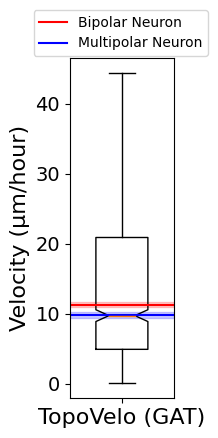

In [11]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch
mask = adata.obs['clusters'].isin(['Radial glia', 'Neuron_5', 'Neuron_15'])
figsize = (2, 4)
fig = plt.figure(figsize=figsize)
plt.boxplot([v_mag_gat[mask]], meanline='r--', notch=True, widths=0.5, showfliers=False)
plt.xticks([1],['TopoVelo (GAT)'], fontsize=16)

xmin, xmax = plt.xlim()
xline = np.array([xmin, xmax])
mean_line_bipolar = np.array([mag_bipolar, mag_bipolar])
mean_line_multipolar = np.array([mag_multipolar, mag_multipolar])
plt.plot(xline, mean_line_bipolar, 'r-', label='Bipolar Neuron')
plt.fill_between(xline, mean_line_bipolar - std_bipolar, mean_line_bipolar + std_bipolar, color='red', alpha=0.2)
plt.plot(xline, mean_line_multipolar, 'b-', label='Multipolar Neuron')
plt.fill_between(xline, mean_line_multipolar - std_multipolar, mean_line_multipolar + std_multipolar, color='blue', alpha=0.2)
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
lgd = fig.legend(handles, labels, bbox_to_anchor=(1.1, 1.1))

plt.yticks(fontsize=14)
plt.ylabel('Velocity (µm/hour)', fontsize=16)
plt.tight_layout()
plt.show()

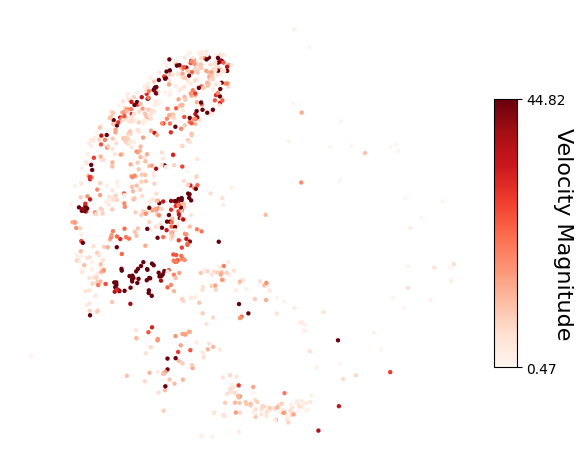

In [12]:
v_mag_gat_sub = v_mag_gat[adata.obs['clusters'].isin(['Radial glia', 'Neuron_5', 'Neuron_15'])]
q1 = np.quantile(v_mag_gat_sub, 0.25)
q3 = np.quantile(v_mag_gat_sub, 0.75)
v_mag_gat_sub = np.clip(v_mag_gat_sub, q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1))

tpv.plotting.plot_heatmap(v_mag_gat_sub,
                          adata_sub.obsm['X_spatial'],
                          width=6,
                          markersize=10,
                          colorbar_name='Velocity Magnitude',
                          #colorbar_ticklabels=['min', 'max'],
                          cmap='Reds',
                          colorbar_fontsize=16,
                          colorbar_tick_fontsize=12,
                          real_aspect_ratio=True)

# Attention Score

## Generalize attention scores to all cells

In [13]:
import torch
import torch_geometric.transforms as gt

In [14]:
model_path = ''
vae = tpv.VAE(adata, 
              tmax=20, 
              dim_z=10, 
              spatial_graph_key='spatial_graph',
              device='cuda:0',
              graph_decoder=True,
              attention=True,
              checkpoints=[f'{model_path}/encoder.pt', f'{model_path}/decoder.pt'])

In [15]:
data = np.concatenate([adata.layers['Mu'], adata.layers['Ms']], 1)
data = torch.tensor(data).float().to(vae.device)
att_enc = vae.get_enc_att_all_pairs(data, adata.n_obs, batch_size=32)

In [16]:
for i in range(5):
    adata.obsp[f'att_score_{i}'] = att_enc[:, :, i]

In [17]:
att_src = att_enc.mean(2).sum(1)

In [18]:
adata.obs['cell_influence_score'] = att_src

In [19]:
cell_anno = adata.obs['clusters'].to_numpy()
cell_labels = np.empty((adata.n_obs), dtype='<U30')
mask_1 = cell_anno == 'Radial glia'
mask_2 = cell_anno == 'Neuron_5'
mask_3 = cell_anno == 'Neuron_15'
mask_4 = cell_anno == 'Fibroblast'
mask_5 = cell_anno == 'Choroid Plexus'
mask_6 = cell_anno == 'White Blood Cells'
mask_7 = cell_anno == 'Endothelial'

cell_labels[mask_1] = 'Radial glia'
cell_labels[mask_2] = 'Neuron Layer 1'
cell_labels[mask_3] = 'Neuron Layer 2'
cell_labels[mask_4] = 'Fibroblast'
cell_labels[mask_5] = 'Choroid Plexus'
cell_labels[mask_6] = 'White Blood Cells'
cell_labels[mask_7] = 'Endothelial'

cell_labels[~(mask_1 | mask_2 | mask_3 | mask_4 | mask_5 | mask_6 | mask_7)] = 'Other Neurons'

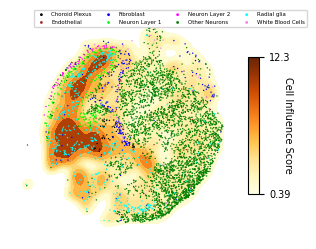

In [20]:
tpv.plotting.DPI = 300
tpv.plotting.plot_heat_density(att_src,
                               adata.obsm['X_spatial'],
                               width=7.5/2.54,
                               radius=50,
                               cell_labels=cell_labels,
                               ncols=4,
                               bbox_to_anchor=[0.2, 1, 1, 0.02],
                               markersize=1,
                               legend_fontsize=4,
                               markerscale=2,
                               palette=['black', 'brown', 'blue', 'lime', 'magenta', 'green', 'cyan', 'violet'],
                               cmap='YlOrBr',
                               colorbar_name='Cell Influence Score')

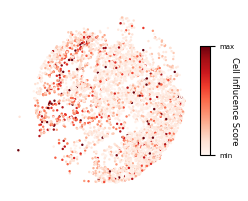

In [21]:
tpv.plotting.plot_heatmap(att_src,
                          adata.obsm['X_spatial'],
                          colorbar_name='Cell Influcence Score',
                          colorbar_ticklabels=['min', 'max'],
                          cmap='Reds',
                          colorbar_fontsize=6,
                          colorbar_tick_fontsize=5,
                          real_aspect_ratio=True)

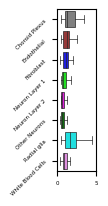

In [22]:
import seaborn
cell_types = np.unique(cell_labels)
att_cluster = [att_src[cell_labels == x] for x in cell_types]
fig, ax = plt.subplots(figsize=(3/2.54, 5.5/2.54))
seaborn.boxplot(att_cluster, orient="h", linewidth=0.5, showfliers=False,
                palette=['gray', 'brown', 'blue', 'lime', 'magenta', 'green', 'cyan', 'violet'],
                ax=ax)
ax.set_yticks(range(len(cell_types)), cell_types, rotation=45, fontsize=4)
ax.set_xticks([0, 5], ['0', '5'], fontsize=4)
plt.tight_layout()
plt.show()


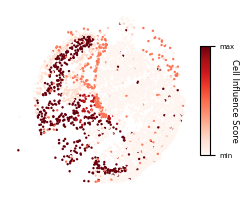

In [23]:
att_cluster = np.zeros((len(att_src)))
for x in cell_types:
    att_cluster[cell_labels == x] = np.mean(att_src[cell_labels == x])
tpv.plotting.plot_heatmap(att_cluster,
                          adata.obsm['X_spatial'],
                          colorbar_name='Cell Influence Score',
                          colorbar_ticklabels=['min', 'max'],
                          cmap='Reds',
                          colorbar_fontsize=6,
                          colorbar_tick_fontsize=5,
                          real_aspect_ratio=True)

In [24]:
mask = adata.obs['clusters'].isin(['Radial glia', 'Neuron_5', 'Neuron_15'])
n_nodes = np.sum(mask)
data = np.concatenate([adata.layers['Mu'][mask], adata.layers['Ms'][mask]], 1)
data = torch.tensor(data).float().to(vae.device)
att_enc_sub = vae.get_enc_att_all_pairs(data, n_nodes, batch_size=32)

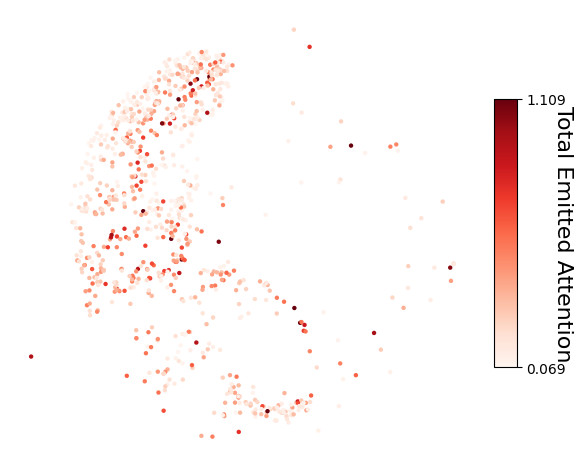

In [25]:
att_src_sub = att_enc[mask][:,mask,:].mean(2).sum(1)
tpv.plotting.plot_heatmap(att_src_sub,
                          adata.obsm['X_spatial'][mask],
                          width=6,
                          markersize=10,
                          colorbar_name='Total Emitted Attention',
                          #colorbar_ticklabels=['min', 'max'],
                          cmap='Reds',
                          colorbar_fontsize=16,
                          colorbar_tick_fontsize=12,
                          real_aspect_ratio=True)

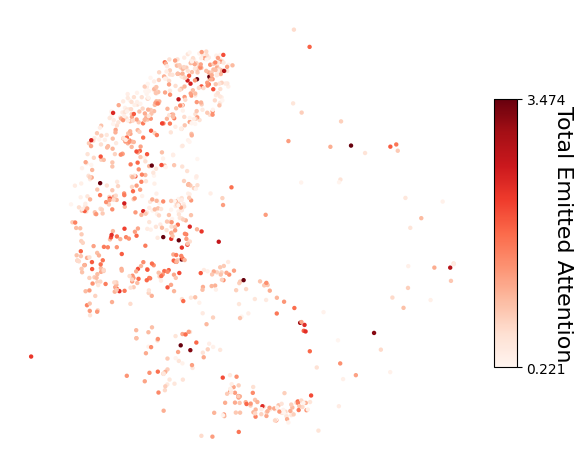

In [26]:
att_src_sub = att_enc_sub.mean(2).sum(1)
tpv.plotting.plot_heatmap(att_src_sub,
                          adata.obsm['X_spatial'][mask],
                          width=6,
                          markersize=10,
                          colorbar_name='Total Emitted Attention',
                          #colorbar_ticklabels=['min', 'max'],
                          cmap='Reds',
                          colorbar_fontsize=16,
                          colorbar_tick_fontsize=12,
                          real_aspect_ratio=True)

## Attention to a Patch

In [27]:
def sample_patch(n_patch, width, x_spatial):
    n_cell = x_spatial.shape[0]
    centers = np.random.permutation(n_cell)[:n_patch]
    x_center = x_spatial[centers]
    # n_cell x n_patch
    isin_patch = np.all(x_spatial.reshape(n_cell, 1, 2) > x_center - width/2, axis=2)
    isin_patch = isin_patch & np.all(x_spatial.reshape(n_cell, 1, 2) < x_center + width/2, axis=2)
    patches = [np.where(isin_patch[:, i])[0] for i in range(n_patch)]
    return centers, patches

In [28]:
def plot_patch_att(att,
                   center_index,
                   patch_indices,
                   width,
                   x_spatial,
                   mode='in',
                   zoom_in_width=None,
                   figsize=None,
                   markersize=10,
                   save=None):
    if figsize is None:
        figsize = tpv.compute_figsize(x_spatial, width=6)
    fig, ax = plt.subplots(figsize=figsize)
    
    ax.scatter(x_spatial[:, 0], x_spatial[:, 1], color='gray', s=markersize, alpha=0.2, edgecolors='none')
    
    # Patch boundary
    top_right = x_spatial[center_index] + width / 2
    top_left = [x_spatial[center_index, 0] - width / 2, x_spatial[center_index, 1] + width / 2]
    bottom_right = [x_spatial[center_index, 0] + width / 2, x_spatial[center_index, 1] - width / 2]
    bottom_left = x_spatial[center_index] - width / 2
    ax.plot([bottom_right[0], top_right[0]], [bottom_right[1], top_right[1]], 'k-')
    ax.plot([top_right[0], top_left[0]], [top_right[1], top_left[1]], 'k-')
    ax.plot([top_left[0], bottom_left[0]], [top_left[1], bottom_left[1]], 'k-')
    ax.plot([bottom_left[0], bottom_right[0]], [bottom_left[1], bottom_right[1]], 'k-')
    
    patch_size = len(patch_indices)
    n_total = len(x_spatial)
    
    if mode == 'in':
        att_plot = att[:, patch_indices].sum(1)
        colorbar_name = "Attention to Patch"
        vmax = 0.05
        vmin = 0
    else:
        att_plot = att[patch_indices].sum(0)
        colorbar_name = "Attention from Patch"
        vmax = 0.05
        vmin = 0
    # print(att_plot.max(), att_plot.min())
    ax = tpv.plotting._plot_heatmap(ax,
                                    att_plot[att_plot > 0],
                                    x_spatial[att_plot > 0],
                                    colorbar_name,
                                    #colorbar_ticklabels=None,
                                    markersize=markersize,
                                    show_colorbar=True,
                                    colorbar_fontsize=16,
                                    #colorbar_limits=[0, 0.05],
                                    colorbar_ticks=None,
                                    colorbar_tick_fontsize=12,
                                    colorbar_pos=[1.04, 0.2, 0.05, 0.6],
                                    cmap='Reds',
                                    axis_off=False)
    if zoom_in_width is not None:
        ax.set_xlim(x_spatial[center_index, 0] - zoom_in_width / 2, x_spatial[center_index, 0] + zoom_in_width / 2)
        ax.set_ylim(x_spatial[center_index, 1] - zoom_in_width / 2, x_spatial[center_index, 1] + zoom_in_width / 2)
    plt.tight_layout()
    if save is not None:
        plt.savefig(save, dpi=300)

In [29]:
x_spatial = adata.obsm['X_spatial'][mask]
att = att_enc_sub.mean(2)
patch_width = 150
centers, patches = sample_patch(2, patch_width, x_spatial)

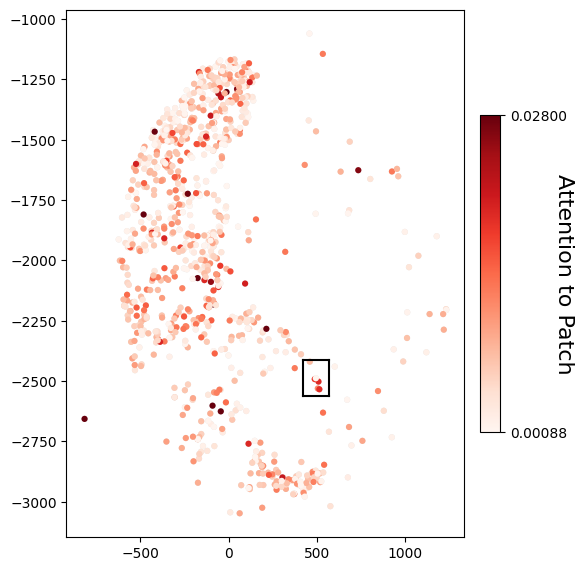

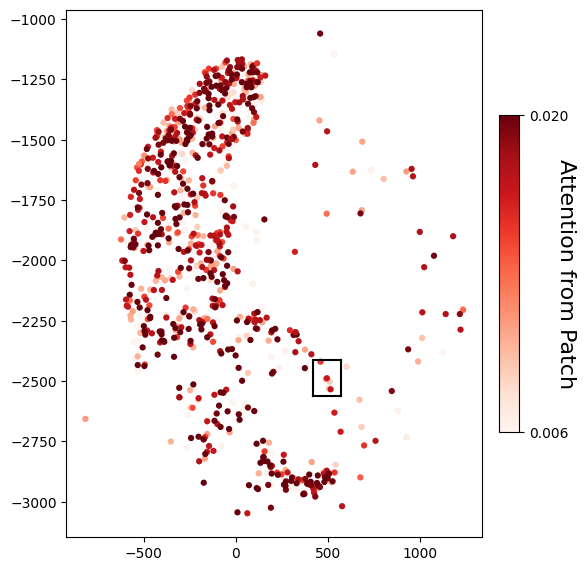

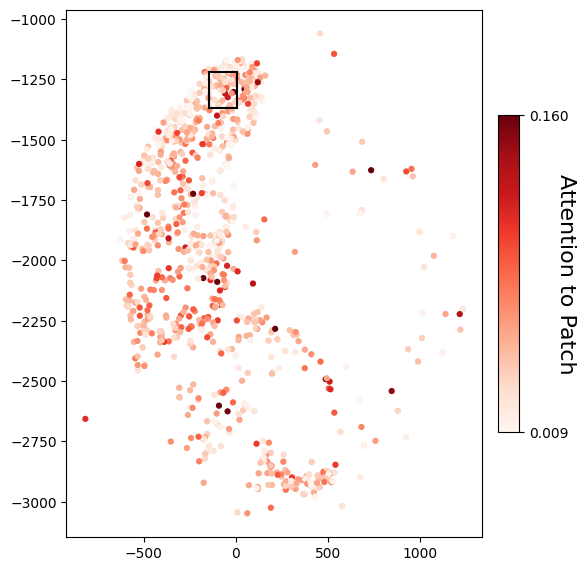

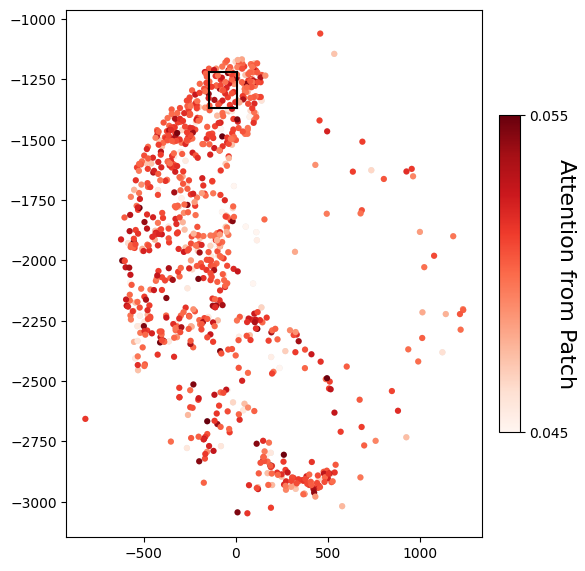

In [30]:
for idx in range(2):
    plot_patch_att(att, centers[idx], patches[idx], patch_width, x_spatial, markersize=20)
    plot_patch_att(att, centers[idx], patches[idx], patch_width, x_spatial, mode='out', markersize=20)